In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_df = pd.read_csv("train_scaled.csv")
test_df = pd.read_csv("test_scaled.csv")

X_train = train_df.drop("target", axis=1)
y_train = train_df["target"]

X_test = test_df.drop("target", axis=1)
y_test = test_df["target"]

print("Datasets loaded!")

Datasets loaded!


In [3]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [4]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Prediction done!")

Prediction done!


In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8852459016393442
Precision: 0.8787878787878788
Recall: 0.90625
F1 Score: 0.8923076923076924


In [6]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Value": [accuracy, precision, recall, f1]
})

results.to_csv("lr_results.csv", index=False)

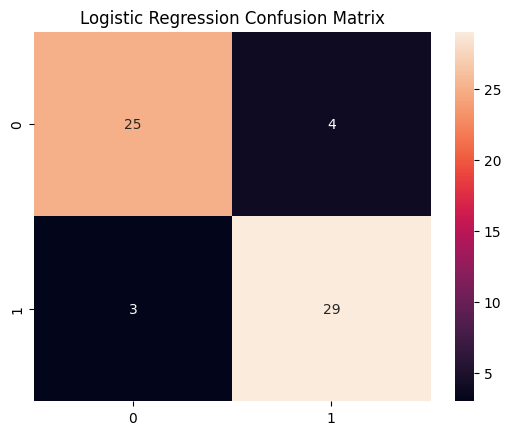

In [7]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Logistic Regression Confusion Matrix")
plt.savefig("lr_confusion_matrix.png")
plt.show()

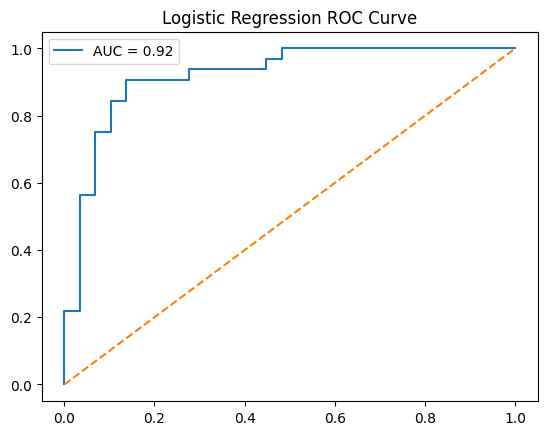

In [8]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.legend()
plt.title("Logistic Regression ROC Curve")
plt.savefig("lr_roc_curve.png")
plt.show()

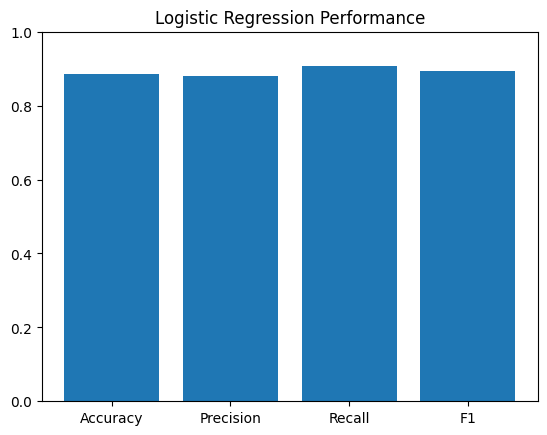

In [9]:
plt.figure()
plt.bar(results["Metric"], results["Value"])
plt.ylim(0, 1)
plt.title("Logistic Regression Performance")
plt.savefig("lr_metrics.png")
plt.show()